# Sentinel-1 Visual Inspection and Direct Registration Check

Two things, both **CPU-only and fast** -- no model, no GPU, no diffusion
sampling.

**1. Look at the data.** Quicklooks of the Sentinel-1 conditioning
alongside the LiDAR target, and an overlay of LiDAR contours on the SAR
image.

**2. Measure the S1-to-LiDAR offset directly.** `dem_unet/05` measures
alignment between the *model's prediction* and the LiDAR, which routes the
question through a trained network and costs a GPU inference run. But a
registration error, if one exists, lives in the **data**, not the model --
so it can be measured between the S1 conditioning and the LiDAR target
directly. That is a cleaner measurement, it needs no GPU, and it runs in
seconds rather than half an hour.

**Why this matters right now.** `05`'s first pass found a monotone ramp in
`dy` running straight into the edge of its +/-5 search window, with the
per-patch votes piled on that boundary -- the signature of an optimum
lying outside the range. If that offset is real it is a property of the
patch extraction, and this notebook will show it far more directly than
re-running inference.

**How to read the result.**
- Peak at (0, 0) -> S1 and LiDAR are aligned; the ramp in `05` is a
  property of the model's output, not the data.
- Peak at a consistent non-zero offset -> a real extraction misregistration.
  Correcting it and re-extracting would raise every correlation metric in
  the study, and the fix is mechanical.
- No peak at all (flat, or incoherent per patch) -> SAR backscatter and
  LiDAR relief are too weakly related at patch level for this test to
  resolve anything, which is itself consistent with the wider argument.

## Setup

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONTEXT_K = 3        # views the model actually uses, matching pcrtc/09
TARGET_HW = (256, 256)

lidar_ids = {p.stem.split('_')[-1] for p in LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)
print(f'paired patches available: {len(paired_ids)}')


def upsample_to(arr, hw):
    """Bilinear upsample a 2-D array to hw -- the same operation the dataset
    applies (F.interpolate, bilinear) before the SAR reaches the model."""
    return zoom(arr, (hw[0] / arr.shape[0], hw[1] / arr.shape[1]), order=1)


def load_patch(pid, k=CONTEXT_K):
    """LiDAR target (demeaned, masked) plus the S1 views, both native and
    upsampled onto the 1m LiDAR grid."""
    with rasterio.open(LIDAR_DIR / f'lidar_patch_{pid}.tif') as src:
        raw = src.read().astype(np.float32)
        transform = src.transform
    tgt = raw[0]
    mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(tgt)
    tgt = np.nan_to_num(tgt, nan=0.0, posinf=0.0, neginf=0.0)
    if mask.sum() > 0:
        tgt = tgt - tgt[mask].mean()

    native, upsampled = [], []
    for t in sorted((S1_DIR / f's1_patch_{pid}').glob('t*.tif'))[:k]:
        with rasterio.open(t) as src:
            sar = src.read()[:2].astype(np.float32)
        sar = 10.0 * np.log10(np.maximum(np.nan_to_num(sar, nan=1e-12), 1e-12))
        native.append(sar)
        upsampled.append(np.stack([upsample_to(sar[0], TARGET_HW),
                                   upsample_to(sar[1], TARGET_HW)]))
    return tgt, mask, native, upsampled, transform


tgt0, mask0, nat0, up0, tr0 = load_patch(paired_ids[0])
n_all = len(sorted((S1_DIR / f's1_patch_{paired_ids[0]}').glob('t*.tif')))
print(f'\nLiDAR target : {tgt0.shape} at {tr0.a:.2f} m/px')
print(f'S1 native    : {nat0[0].shape} (2 pol) -- ~{256 / nat0[0].shape[1]:.1f} m/px')
print(f'S1 upsampled : {up0[0].shape} (what the model sees, bilinear)')
print(f'Temporal views on disk: {n_all}; the model uses CONTEXT_K = {CONTEXT_K}')
print(f'\nUpsampling factor: {TARGET_HW[0] / nat0[0].shape[1]:.1f}x. One native SAR pixel')
print(f'covers ~{256 / nat0[0].shape[1]:.0f} LiDAR pixels, so any offset below that is SUB-PIXEL')
print('in the source data and cannot be resolved by a shift sweep on the SAR.')

paired patches available: 1676

LiDAR target : (256, 256) at 1.00 m/px
S1 native    : (2, 26, 26) (2 pol) -- ~9.8 m/px
S1 upsampled : (2, 256, 256) (what the model sees, bilinear)
Temporal views on disk: 7; the model uses CONTEXT_K = 3

Upsampling factor: 9.8x. One native SAR pixel
covers ~10 LiDAR pixels, so any offset below that is SUB-PIXEL
in the source data and cannot be resolved by a shift sweep on the SAR.


## 1. Quicklooks

Top rows are the Sentinel-1 VV views the model sees as conditioning; the
bottom row is the LiDAR target. The SAR is at ~10 m native resolution
resampled onto the 1 m LiDAR grid, so it looks blocky next to the LiDAR --
that resolution mismatch is inherent to the problem, not an artifact.

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_lidar_quicklook.png


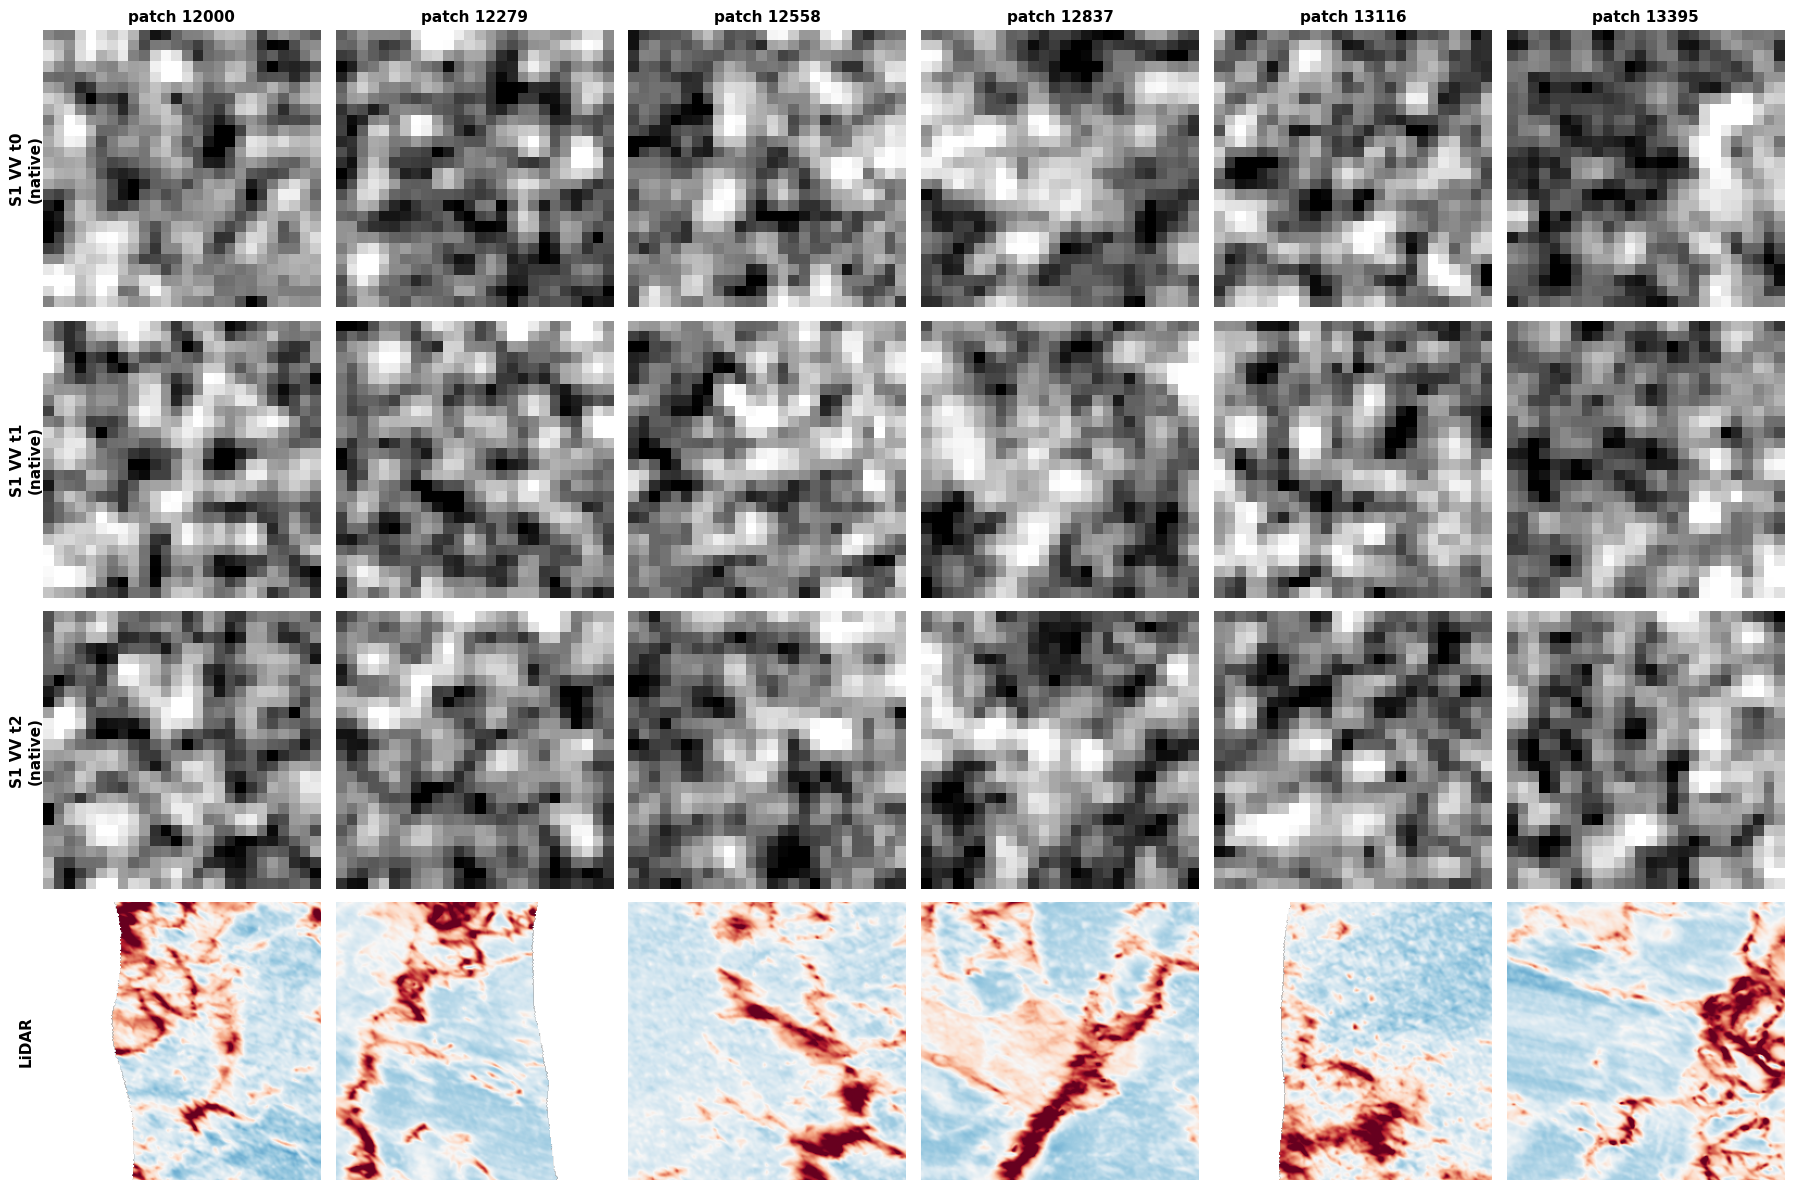

In [2]:
N_SHOW = 6
sample_ids = paired_ids[::max(1, len(paired_ids) // N_SHOW)][:N_SHOW]

n_views = len(up0)
fig, axes = plt.subplots(n_views + 1, N_SHOW,
                         figsize=(3.0 * N_SHOW, 3.0 * (n_views + 1)), squeeze=False)
for col, pid in enumerate(sample_ids):
    tgt, mask, native, views, _ = load_patch(pid)
    axes[0, col].set_title(f'patch {pid}', fontsize=11, fontweight='bold')
    for k in range(n_views):
        vv = native[k][0]   # native 26x26 -- what the sensor actually recorded
        lo, hi = np.percentile(vv, [2, 98])
        axes[k, col].imshow(vv, cmap='gray', vmin=lo, vmax=hi)
        axes[k, col].axis('off')
    v = np.percentile(np.abs(tgt[mask]), 98) if mask.sum() else 1.0
    axes[n_views, col].imshow(np.where(mask, tgt, np.nan), cmap='RdBu_r', vmin=-v, vmax=v)
    axes[n_views, col].axis('off')

for k in range(n_views):
    axes[k, 0].text(-0.06, 0.5, f'S1 VV t{k}\n(native)', transform=axes[k, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=11, fontweight='bold')
axes[n_views, 0].text(-0.06, 0.5, 'LiDAR', transform=axes[n_views, 0].transAxes,
                      rotation=90, va='center', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
out = OUTPUT_DIR / 's1_lidar_quicklook.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print('Saved:', out)
plt.show()

## 2. VV, VH and their ratio

The two polarisations respond differently to surface structure. The model
receives both (repeated to fill four channels), so it is worth seeing what
each actually contains before interpreting what the model does with them.

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_polarisation_check.png
VV range -27.5 to -13.7 dB, std 2.17
VH range -31.6 to -22.2 dB, std 1.64


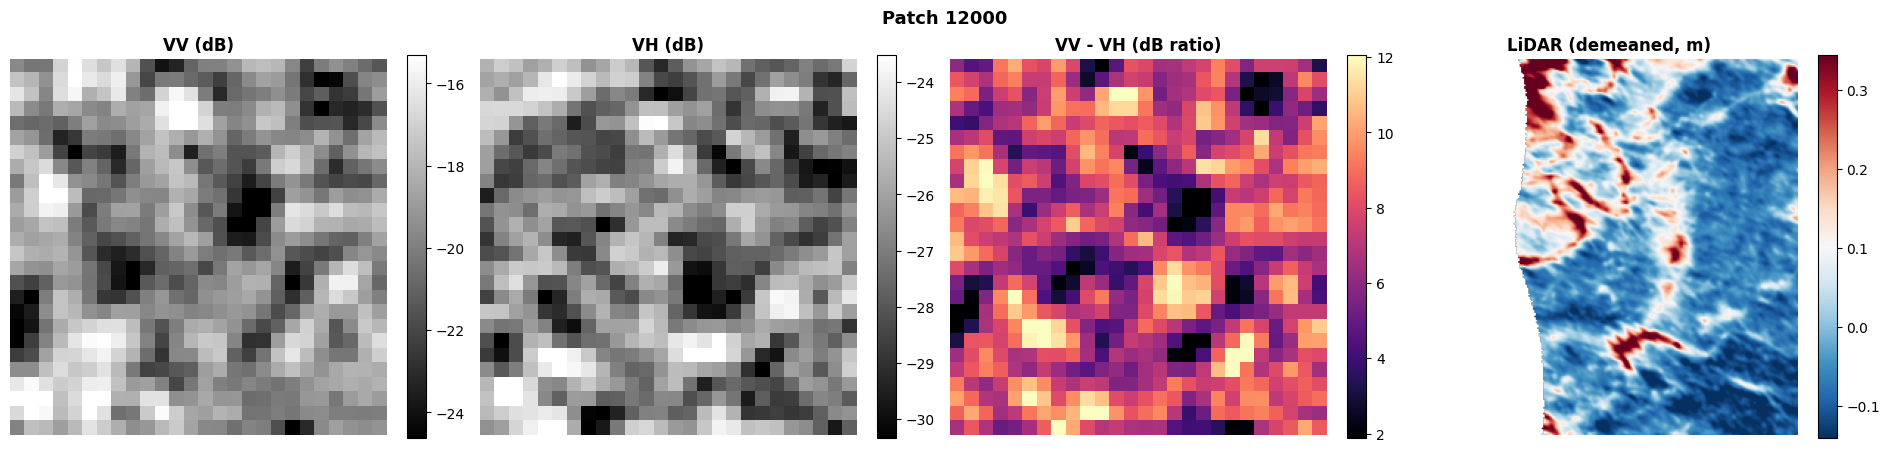

In [3]:
pid = sample_ids[0]
tgt, mask, native, views, _ = load_patch(pid)
vv, vh = native[0][0], native[0][1]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
for ax, (img, title, cmap) in zip(axes, [
        (vv, 'VV (dB)', 'gray'),
        (vh, 'VH (dB)', 'gray'),
        (vv - vh, 'VV - VH (dB ratio)', 'magma'),
        (np.where(mask, tgt, np.nan), 'LiDAR (demeaned, m)', 'RdBu_r')]):
    lo, hi = np.nanpercentile(img, [2, 98])
    im = ax.imshow(img, cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f'Patch {pid}', fontsize=13, fontweight='bold')
plt.tight_layout()
out = OUTPUT_DIR / 's1_polarisation_check.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print('Saved:', out)
print(f'VV range {vv.min():.1f} to {vv.max():.1f} dB, std {vv.std():.2f}')
print(f'VH range {vh.min():.1f} to {vh.max():.1f} dB, std {vh.std():.2f}')
plt.show()

## 3. Overlay -- LiDAR contours on the SAR image

If the two are registered, high-relief LiDAR contours should sit on
features visible in the SAR. A consistent displacement in one direction
across patches is a registration error you can see rather than infer.

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_lidar_overlay.png


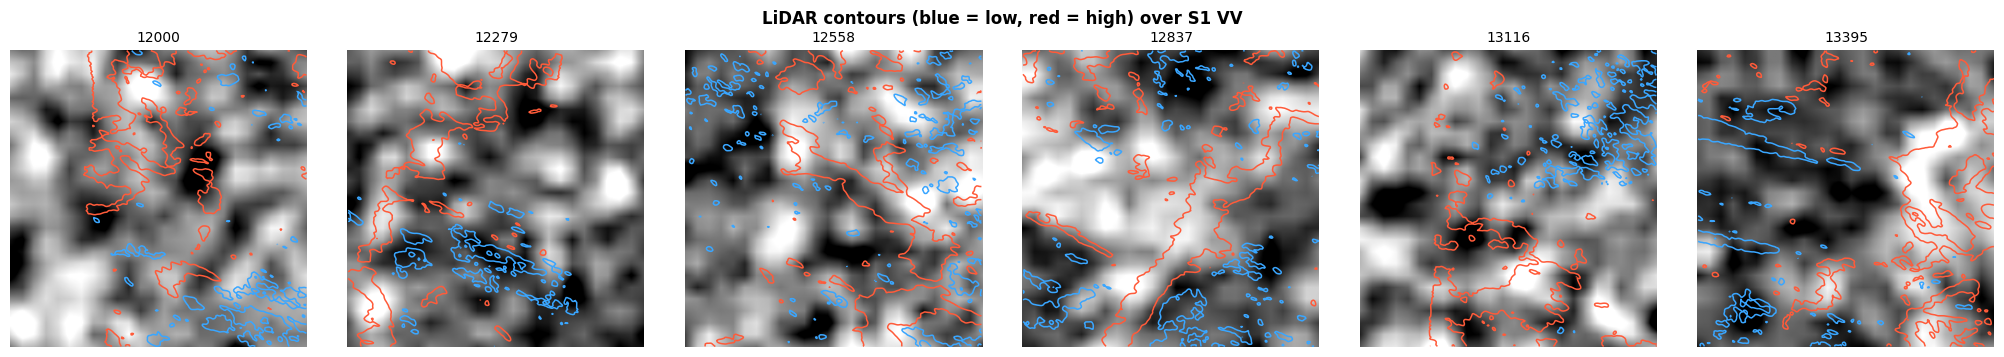

In [4]:
fig, axes = plt.subplots(1, N_SHOW, figsize=(3.4 * N_SHOW, 3.6), squeeze=False)
for col, pid in enumerate(sample_ids):
    tgt, mask, native, views, _ = load_patch(pid)
    vv = views[0][0]   # upsampled, so it shares the LiDAR grid
    lo, hi = np.percentile(vv, [2, 98])
    ax = axes[0, col]
    ax.imshow(vv, cmap='gray', vmin=lo, vmax=hi)
    sm = np.where(mask, tgt, 0.0)
    lvl = np.percentile(np.abs(sm[mask]), 80) if mask.sum() else 0.1
    ax.contour(sm, levels=[-lvl, lvl], colors=['#3aa6ff', '#ff5b3a'], linewidths=1.1)
    ax.set_title(f'{pid}', fontsize=10)
    ax.axis('off')
plt.suptitle('LiDAR contours (blue = low, red = high) over S1 VV', fontsize=12, fontweight='bold')
plt.tight_layout()
out = OUTPUT_DIR / 's1_lidar_overlay.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print('Saved:', out)
plt.show()

## 4. The direct registration measurement

Correlate the **S1 conditioning against the LiDAR target** over a grid of
shifts. No model, no GPU. Two variants, because the physical relationship
is not guaranteed to be sign-consistent:

- **raw**: VV in dB against demeaned LiDAR elevation.
- **gradient**: |grad VV| against |grad LiDAR|. This is the more sensible
  one for registration -- both are edge maps, so alignment shows up as a
  peak regardless of whether high backscatter means high or low ground.

Absolute correlation is used throughout, since only the *location* of the
peak matters here, not its sign.

In [5]:
from scipy.signal import fftconvolve

DY_RANGE = (-20, 20)
DX_RANGE = (-20, 20)
N_PATCHES = 250

def norm_xcorr_surface(a, b, max_shift):
    """Normalised cross-correlation surface via FFT, cropped to +/-max_shift.
    O(N log N) per patch instead of one pass per offset."""
    a = a - a.mean()
    b = b - b.mean()
    na, nb_ = np.sqrt((a * a).sum()), np.sqrt((b * b).sum())
    if na < 1e-12 or nb_ < 1e-12:
        return None
    full = fftconvolve(b, a[::-1, ::-1], mode='same') / (na * nb_)
    cy, cx = full.shape[0] // 2, full.shape[1] // 2
    return full[cy - max_shift:cy + max_shift + 1, cx - max_shift:cx + max_shift + 1]

def grad_mag(x):
    gy, gx = np.gradient(x.astype(np.float64))
    return np.hypot(gy, gx)

MS = max(abs(v) for v in DY_RANGE + DX_RANGE)
use_ids = paired_ids[::max(1, len(paired_ids) // N_PATCHES)][:N_PATCHES]

sum_raw = np.zeros((2 * MS + 1, 2 * MS + 1))
sum_grd = np.zeros((2 * MS + 1, 2 * MS + 1))
votes_raw, votes_grd = Counter(), Counter()
n_used = 0

for n, pid in enumerate(use_ids):
    tgt, mask, native, upsampled, _ = load_patch(pid)
    if mask.sum() < 1000:
        continue
    vv = upsampled[0][0]              # on the 1m grid, as the model receives it
    t = np.where(mask, tgt, 0.0)
    sr = norm_xcorr_surface(t, vv, MS)
    sg = norm_xcorr_surface(grad_mag(t), grad_mag(vv), MS)
    if sr is None or sg is None:
        continue
    sum_raw += np.abs(sr)
    sum_grd += np.abs(sg)
    for surf, votes in ((np.abs(sr), votes_raw), (np.abs(sg), votes_grd)):
        iy, ix = np.unravel_index(np.argmax(surf), surf.shape)
        votes[(iy - MS, ix - MS)] += 1
    n_used += 1
    if (n + 1) % 50 == 0:
        print(f'  {n + 1}/{len(use_ids)}')

assert n_used, 'No usable patches.'
mean_raw, mean_grd = sum_raw / n_used, sum_grd / n_used
print(f'patches used: {n_used}')

surf_raw = {(y - MS, x - MS): float(mean_raw[y, x])
            for y in range(2 * MS + 1) for x in range(2 * MS + 1)}
surf_grd = {(y - MS, x - MS): float(mean_grd[y, x])
            for y in range(2 * MS + 1) for x in range(2 * MS + 1)}

native_px_m = 256 / load_patch(use_ids[0])[2][0].shape[1]
print(f'\nNative SAR pixel ~= {native_px_m:.0f} m. Offsets smaller than this are')
print('sub-pixel in the source and are not resolvable here, however sharp the peak looks.')

for name, surf, votes in [('raw VV vs elevation', surf_raw, votes_raw),
                          ('gradient vs gradient', surf_grd, votes_grd)]:
    best = max(surf, key=surf.get)
    at0 = surf[(0, 0)]
    rng = max(surf.values()) - min(surf.values())
    on_edge = best[0] in DY_RANGE or best[1] in DX_RANGE
    top = votes.most_common(3)
    print(f'\n{name}:')
    print(f'  |corr| at (0,0)      : {at0:.4f}')
    print(f'  peak {best}          : {surf[best]:.4f}   ({surf[best] - at0:+.4f})')
    print(f'  surface range        : {rng:.4f}')
    print(f'  peak on search edge? : {"YES -- widen the range" if on_edge else "no"}')
    print(f'  |peak| vs native px  : {max(abs(best[0]), abs(best[1])) / native_px_m:.2f} SAR pixels')
    print(f'  per-patch argmax top3: {top}')
    print(f'  fraction at modal    : {top[0][1] / n_used:.0%} (chance = {1 / len(surf):.1%})')

json.dump({'raw': {f'{k[0]},{k[1]}': v for k, v in surf_raw.items()},
           'grad': {f'{k[0]},{k[1]}': v for k, v in surf_grd.items()},
           'votes_raw': {f'{k[0]},{k[1]}': v for k, v in votes_raw.items()},
           'votes_grad': {f'{k[0]},{k[1]}': v for k, v in votes_grd.items()},
           'n_patches': n_used, 'dy_range': DY_RANGE, 'dx_range': DX_RANGE,
           'native_px_m': native_px_m},
          (OUTPUT_DIR / 's1_lidar_direct_shift_sweep.json').open('w'), indent=2)
print('\nSaved:', OUTPUT_DIR / 's1_lidar_direct_shift_sweep.json')

  50/250
  100/250
  150/250
  200/250
  250/250
patches used: 250

Native SAR pixel ~= 10 m. Offsets smaller than this are
sub-pixel in the source and are not resolvable here, however sharp the peak looks.

raw VV vs elevation:
  |corr| at (0,0)      : 0.2874
  peak (-9, 0)          : 0.3119   (+0.0244)
  surface range        : 0.1890
  peak on search edge? : no
  |peak| vs native px  : 0.91 SAR pixels
  per-patch argmax top3: [((np.int64(0), np.int64(0)), 11), ((np.int64(-8), np.int64(0)), 8), ((np.int64(-5), np.int64(0)), 6)]
  fraction at modal    : 4% (chance = 0.1%)

gradient vs gradient:
  |corr| at (0,0)      : 0.0451
  peak (1, 0)          : 0.0451   (+0.0000)
  surface range        : 0.0122
  peak on search edge? : no
  |peak| vs native px  : 0.10 SAR pixels
  per-patch argmax top3: [((np.int64(-20), np.int64(20)), 5), ((np.int64(-20), np.int64(-20)), 4), ((np.int64(5), np.int64(20)), 3)]
  fraction at modal    : 2% (chance = 0.1%)

Saved: /cs/student/project_msc/2025/aibh/ji

## 5. The surfaces

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_lidar_direct_shift_surface.png


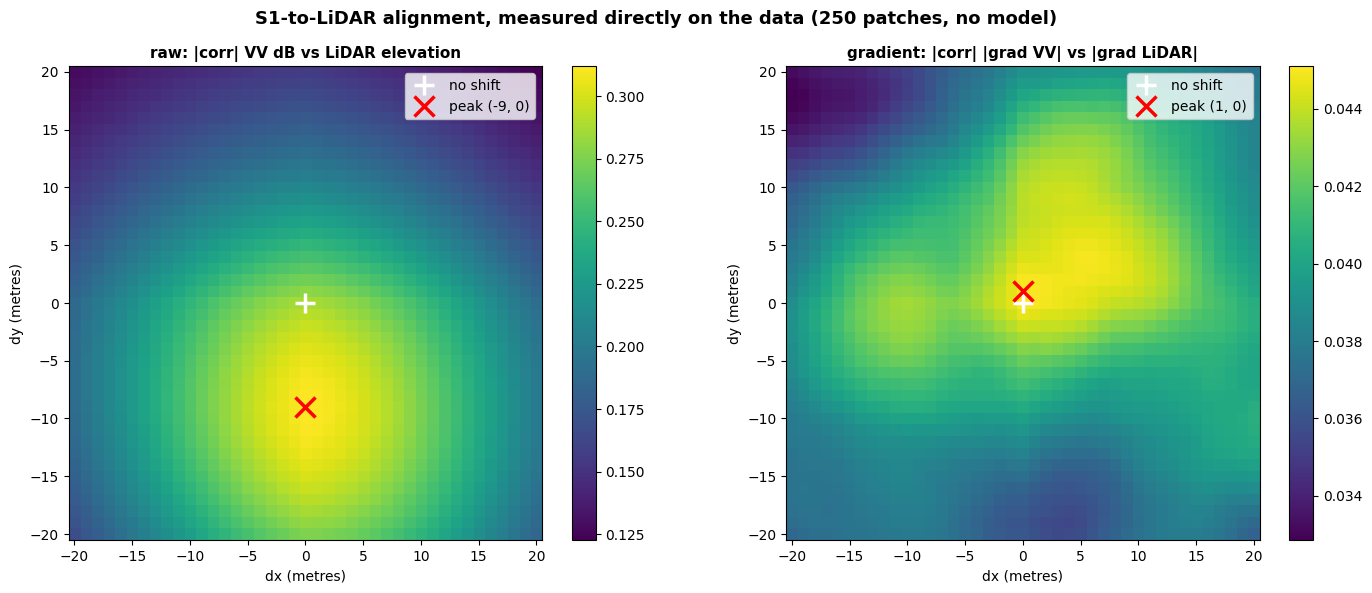

In [6]:
n_dy = DY_RANGE[1] - DY_RANGE[0] + 1
n_dx = DX_RANGE[1] - DX_RANGE[0] + 1

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))
for ax, (surf, title) in zip(axes, [(surf_raw, 'raw: |corr| VV dB vs LiDAR elevation'),
                                    (surf_grd, 'gradient: |corr| |grad VV| vs |grad LiDAR|')]):
    g = np.full((n_dy, n_dx), np.nan)
    for (dy, dx), v in surf.items():
        g[dy - DY_RANGE[0], dx - DX_RANGE[0]] = v
    im = ax.imshow(g, cmap='viridis', origin='lower',
                   extent=[DX_RANGE[0] - .5, DX_RANGE[1] + .5, DY_RANGE[0] - .5, DY_RANGE[1] + .5])
    best = max(surf, key=surf.get)
    ax.plot(0, 0, 'w+', markersize=15, markeredgewidth=2.5, label='no shift')
    ax.plot(best[1], best[0], 'rx', markersize=15, markeredgewidth=2.5, label=f'peak {best}')
    ax.set_xlabel('dx (metres)')
    ax.set_ylabel('dy (metres)')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(loc='upper right')
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f'S1-to-LiDAR alignment, measured directly on the data ({n_used} patches, no model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = OUTPUT_DIR / 's1_lidar_direct_shift_surface.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print('Saved:', out)
plt.show()

## What the answer means

**Peak at or near (0, 0)** -- the data are registered. The ramp `05` found
is then a property of the model's output, not of the extraction, and the
unshifted ZNCC stands as the headline. Say so in Methods in one sentence;
it closes the question with a measurement.

**Peak at a consistent non-zero offset** -- a real extraction
misregistration, and the most valuable finding available at this stage.
Every correlation metric in the study is depressed by it, the cause is in
the patch extraction, and the fix is mechanical. Report the measured
offset and, if there is time, re-extract and re-evaluate; if there is not,
report it as a quantified limitation with the magnitude stated.

**Flat or incoherent, especially in the gradient panel** -- backscatter
and relief are too weakly related at patch scale for this to resolve.
That is a null result for registration, but it is *evidence* for the wider
argument: if the two edge maps do not correlate at any alignment, the
information the model needs is not present in the conditioning.